In [6]:
import pandas as pd


In [7]:
df = pd.read_csv("career_skills_raw.csv")

In [8]:
print(df.shape)

(1872, 38)


In [9]:
df.head(10)

,respondent_id,submitted_on,education_level,experience_years,python,java,c_cpp,javascript,typescript,html_css,...,linux,aws,azure_gcp,ci_cd,terraform,cybersecurity_basics,penetration_testing,flutter_react_native,target_career,remarks
0,R1704,17/04/2025,No formal degree,zero,No,0,No,1,yes,Yes,...,0,No,False,0,0,0,Y,0,Frontend Developer,NaN
1,R1226,19/07/2025,BSC CS / IT,2,No,N,0,yes,1,1,...,0,0,0,N,0,no,No,N,Frontend Developer,NaN
2,R1461,02 Nov 2025,b.tech,3,Yes,9,N,No,False,no,...,No,False,1,not known,1,1,0,-,cloud architect,NaN
3,R0276,31.12.25,Self-Taught,99,1,N,0,no,0,No,...,no,0,FALSE,Y,0,0,0,0,ML Engineer,NaN
4,R0417,"August 11, 2025",M.Tech / MCA,<1,0,Yes,1,False,0,no,...,True,0,0,1,not known,0,NaN,0,DBA,duplicate?
5,r-1035,14.11.25,BCA,3,0,NaN,0,TRUE,No,1,...,0,0,0,0,N,0,No,0,front end developer,NaN
6,R0248,26 Feb 2026,BSC CS / IT,1,Yes,0.0,NaN,0,N,0,...,Yes,1,0,No,no,False,No,0,DATA ANALYST,NaN
7,R0384,"July 14, 2026",Masters (M.Tech/MCA),fresher,No,0,0,Yes,1,No,...,0,No,0,No,No,0,0,0,MOBILE APP DEVELOPER,NaN
8,R0323,04/06/2025,B.E.,0,TRUE,N,Yes,0,False,0,...,0,1,False,0.0,0.0,no,0,0,Machine Learning Engineer,NaN
9,R0204,20 Jul 2025,B.TECH / B.E.,0,TRUE,,0,0,No,not known,...,NaN,0,0,0,0,0,0,1,AI Engineer,NaN


In [10]:
df.isnull().sum()

,0
respondent_id,0
submitted_on,0
education_level,47
experience_years,68
python,66
java,52
c_cpp,70
javascript,56
typescript,52
html_css,17


In [11]:
print(df.isnull().sum()[df.isnull().sum() > 0])

education_level           47
experience_years          68
python                    66
java                      52
c_cpp                     70
javascript                56
typescript                52
html_css                  17
react                     20
angular_vue               55
nodejs                    34
fastapi_flask             24
django                    32
sql                       27
nosql                     74
mongodb                   32
postgresql                61
pandas_numpy              43
scikit_learn              20
deep_learning             13
pytorch_tensorflow        66
nlp                       53
computer_vision           63
docker                    48
kubernetes                43
git                       58
linux                     43
aws                       71
azure_gcp                 39
ci_cd                     41
terraform                 48
cybersecurity_basics      41
penetration_testing       33
flutter_react_native      34
target_career 

In [12]:
missing_percent = df.isnull().mean() * 100

In [13]:
print(missing_percent[missing_percent > 0])

education_level          2.510684
experience_years         3.632479
python                   3.525641
java                     2.777778
c_cpp                    3.739316
javascript               2.991453
typescript               2.777778
html_css                 0.908120
react                    1.068376
angular_vue              2.938034
nodejs                   1.816239
fastapi_flask            1.282051
django                   1.709402
sql                      1.442308
nosql                    3.952991
mongodb                  1.709402
postgresql               3.258547
pandas_numpy             2.297009
scikit_learn             1.068376
deep_learning            0.694444
pytorch_tensorflow       3.525641
nlp                      2.831197
computer_vision          3.365385
docker                   2.564103
kubernetes               2.297009
git                      3.098291
linux                    2.297009
aws                      3.792735
azure_gcp                2.083333
ci_cd         

In [14]:
print(df.duplicated().sum())

54


In [15]:
df = df.drop_duplicates()

In [16]:
print(df.duplicated().sum())

0


In [17]:
df = df.drop(columns=["respondent_id", "submitted_on", "remarks"])

In [18]:
print(df.shape)

(1818, 35)


In [19]:
print(df.columns)

Index(['education_level', 'experience_years', 'python', 'java', 'c_cpp',
       'javascript', 'typescript', 'html_css', 'react', 'angular_vue',
       'nodejs', 'fastapi_flask', 'django', 'sql', 'nosql', 'mongodb',
       'postgresql', 'pandas_numpy', 'scikit_learn', 'deep_learning',
       'pytorch_tensorflow', 'nlp', 'computer_vision', 'docker', 'kubernetes',
       'git', 'linux', 'aws', 'azure_gcp', 'ci_cd', 'terraform',
       'cybersecurity_basics', 'penetration_testing', 'flutter_react_native',
       'target_career'],
      dtype='object')


In [20]:
df["experience_years"] = (
    df["experience_years"]
    .astype(str)
    .str.lower()
    .str.strip()
)

In [21]:
df["experience_years"] = df["experience_years"].replace({
    "zero": "0",
    "one": "1",
    "two": "2",
    "three": "3"
})

In [22]:
df["experience_years"] = (df["experience_years"].str.extract(r"(\d+)")[0])

In [23]:
df["experience_years"] = pd.to_numeric(df["experience_years"],errors="coerce")

In [24]:
print(df["experience_years"].value_counts(dropna=False))

experience_years
1.0     585
0.0     549
3.0     300
2.0     251
NaN     115
25.0      6
45.0      5
20.0      4
99.0      3
Name: count, dtype: int64


In [25]:
df["experience_years"] = df["experience_years"].fillna(
    df["experience_years"].median()
)

In [26]:
df["experience_years"] = df["experience_years"].astype(int)

In [27]:
df["experience_years"].describe()

,experience_years
count,1818.000000
mean,1.569857
std,4.965574
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,99.000000


In [28]:
df = df[
    (df["experience_years"] >= 0) &
    (df["experience_years"] <= 3)
]

In [29]:
skill_columns = [
    "python",
    "java",
    "c_cpp",
    "javascript",
    "typescript",
    "html_css",
    "react",
    "angular_vue",
    "nodejs",
    "fastapi_flask",
    "django",
    "sql",
    "nosql",
    "mongodb",
    "postgresql",
    "pandas_numpy",
    "scikit_learn",
    "deep_learning",
    "pytorch_tensorflow",
    "nlp",
    "computer_vision",
    "docker",
    "kubernetes",
    "git",
    "linux",
    "aws",
    "azure_gcp",
    "ci_cd",
    "terraform",
    "cybersecurity_basics",
    "penetration_testing",
    "flutter_react_native"
]

In [30]:
def clean_binary(value):
    value = str(value).strip().lower()
    if value in ["yes", "y", "true", "1", "1.0"]:
        return 1
    elif value in ["no", "n", "false", "0", "0.0"]:
        return 0
    else:
        return None

In [31]:
for col in skill_columns:
    df[col] = df[col].apply(clean_binary)

In [32]:
df[skill_columns].head()

,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,fastapi_flask,...,kubernetes,git,linux,aws,azure_gcp,ci_cd,terraform,cybersecurity_basics,penetration_testing,flutter_react_native
0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,NaN,1.0,1.0,0.0,NaN
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,1.0,1.0,0.0,0.0,1.0,NaN,0.0,NaN,0.0
5,0.0,NaN,0.0,1.0,0.0,1.0,1.0,NaN,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
df[skill_columns].isnull().sum

<bound method DataFrame.sum of       python   java  c_cpp  javascript  typescript  html_css  react  \
0      False  False  False       False       False     False  False   
1      False  False  False       False       False     False  False   
2      False   True  False       False       False     False  False   
4      False  False  False       False       False     False  False   
5      False   True  False       False       False     False  False   
...      ...    ...    ...         ...         ...       ...    ...   
1867   False  False  False       False       False     False  False   
1868   False  False  False       False       False     False  False   
1869   False  False  False       False       False     False  False   
1870   False  False  False       False       False     False  False   
1871   False  False  False       False       False     False  False   

      angular_vue  nodejs  fastapi_flask  ...  kubernetes    git  linux  \
0           False   False          False  ...       False  False  False   
1           False   False          False  ...       False  False  False   
2           False   False          False  ...       False  False  False   
4           False   False           True  ...       False  False  False   
5            True   False          False  ...       False  False  False   
...           ...     ...            ...  ...         ...    ...    ...   
1867        False   False          False  ...       False  False  False   
1868        False   False          False  ...        True  False  False   
1869        False   False           True  ...       False  False  False   
1870        False   False          False  ...       False  False  False   
1871        False   False          False  ...       False  False  False   

        aws  azure_gcp  ci_cd  terraform  cybersecurity_basics  \
0     False      False  False      False                 False   
1     False      False  False      False                 False   
2     False      False   True      False                 False   
4     False      False  False       True                 False   
5     False      False  False      False                 False   
...     ...        ...    ...        ...                   ...   
1867  False      False  False      False                 False   
1868   True      False  False      False                 False   
1869  False      False  False      False                 False   
1870  False      False  False      False                 False   
1871  False      False  False      False                 False   

      penetration_testing  flutter_react_native  
0                   False                 False  
1                   False                 False  
2                   False                  True  
4                    True                 False  
5                   False                 False  
...                   ...                   ...  
1867                False                 False  
1868                False                 False  
1869                False                 False  
1870                False                  True  
1871                False                 False  

[1800 rows x 32 columns]>

In [34]:
for col in skill_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [35]:
for col in skill_columns:
    df[col] = df[col].astype(int)

In [36]:
print(df[skill_columns].isnull().sum().sum())

0


In [37]:
df["education_level"] = (
    df["education_level"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [38]:
def clean_education(value):
    if "bca" in value or "computer application" in value:
        return "BCA"
    elif "b.tech" in value or "btech" in value or "bachelor of technology" in value:
        return "B.Tech / B.E."
    elif "b.sc" in value or "bsc" in value:
        return "B.Sc CS / IT"
    elif "m.tech" in value or "mca" in value or "master" in value:
        return "M.Tech / MCA"
    elif "self" in value:
        return "Self-Taught"
    else:
        return None

In [39]:
print(df["education_level"].value_counts(dropna=False))

education_level
bca                                  179
self taught                          100
m.tech                               100
b.tech                                92
self-taught                           89
b.tech / b.e.                         88
b.c.a.                                61
selftaught                            60
b.sc it                               59
no formal degree                      57
b.sc cs/it                            54
m.c.a                                 53
b.c.a                                 53
masters (m.tech/mca)                  53
bachelor of technology                52
m.tech / mca                          52
bachelor of computer applications     51
b.sc. computer science                51
bsc cs                                50
self learner                          49
mca                                   48
nan                                   47
btech                                 45
bsc cs / it                           44


In [40]:
df["education_level"] = df["education_level"].apply(clean_education)

In [41]:
df["education_level"] = df["education_level"].fillna(df["education_level"].mode()[0])

In [42]:
df["target_career"] = (
    df["target_career"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [43]:
def clean_career(value):

    if "data scientist" in value or "data science" in value:
        return "Data Scientist"
    elif "data analyst" in value:
        return "Data Analyst"
    elif "machine learning" in value or "ml engineer" in value:
        return "Machine Learning Engineer"
    elif "artificial intelligence" in value or "ai engineer" in value:
        return "AI Engineer"
    elif "front" in value:
        return "Frontend Developer"
    elif "back" in value:
        return "Backend Developer"
    elif "full stack" in value:
        return "Full Stack Developer"
    elif "devops" in value:
        return "DevOps Engineer"
    elif "cloud" in value:
        return "Cloud Architect"
    elif "database" in value:
        return "Database Administrator"
    elif "cyber" in value:
        return "Cybersecurity Analyst"
    elif "mobile" in value:
        return "Mobile App Developer"
    else:
        return None

In [44]:
df["target_career"] = df["target_career"].apply(clean_career)

In [45]:
df = df.dropna(subset=["target_career"])

In [46]:
print(df.isnull().sum())

education_level         0
experience_years        0
python                  0
java                    0
c_cpp                   0
javascript              0
typescript              0
html_css                0
react                   0
angular_vue             0
nodejs                  0
fastapi_flask           0
django                  0
sql                     0
nosql                   0
mongodb                 0
postgresql              0
pandas_numpy            0
scikit_learn            0
deep_learning           0
pytorch_tensorflow      0
nlp                     0
computer_vision         0
docker                  0
kubernetes              0
git                     0
linux                   0
aws                     0
azure_gcp               0
ci_cd                   0
terraform               0
cybersecurity_basics    0
penetration_testing     0
flutter_react_native    0
target_career           0
dtype: int64


In [47]:
print( df.duplicated().sum())

18


In [48]:
df = df.drop_duplicates()

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
print("Final shape:", df.shape)

Final shape: (1399, 35)


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
print("Shape:", df.shape)


Shape: (1399, 35)


In [53]:
print(df.columns)

Index(['education_level', 'experience_years', 'python', 'java', 'c_cpp',
       'javascript', 'typescript', 'html_css', 'react', 'angular_vue',
       'nodejs', 'fastapi_flask', 'django', 'sql', 'nosql', 'mongodb',
       'postgresql', 'pandas_numpy', 'scikit_learn', 'deep_learning',
       'pytorch_tensorflow', 'nlp', 'computer_vision', 'docker', 'kubernetes',
       'git', 'linux', 'aws', 'azure_gcp', 'ci_cd', 'terraform',
       'cybersecurity_basics', 'penetration_testing', 'flutter_react_native',
       'target_career'],
      dtype='object')


In [54]:
df.describe()

,experience_years,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,...,kubernetes,git,linux,aws,azure_gcp,ci_cd,terraform,cybersecurity_basics,penetration_testing,flutter_react_native
count,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,...,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000
mean,1.170122,0.634739,0.167262,0.100786,0.216583,0.215154,0.167977,0.165833,0.075768,0.203002,...,0.208721,0.714081,0.468906,0.408149,0.175125,0.267334,0.191565,0.150822,0.108649,0.106505
std,1.035670,0.481675,0.373343,0.301153,0.412064,0.411076,0.373980,0.372063,0.264722,0.402378,...,0.406540,0.452012,0.499211,0.491667,0.380210,0.442726,0.393674,0.358003,0.311310,0.308593
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [55]:
df["target_career"].value_counts()

,count
target_career,
Cloud Architect,150
Backend Developer,127
Frontend Developer,126
Machine Learning Engineer,125
DevOps Engineer,125
Data Analyst,124
Data Scientist,124
Mobile App Developer,123
Cybersecurity Analyst,103


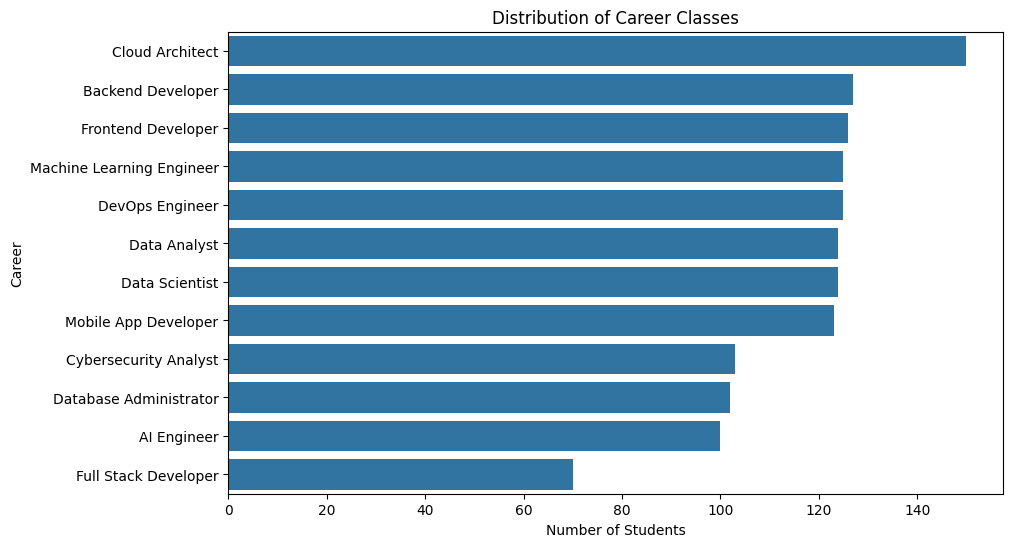

In [56]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    y="target_career",
    order=df["target_career"].value_counts().index)
plt.title("Distribution of Career Classes")
plt.xlabel("Number of Students")
plt.ylabel("Career")
plt.show()

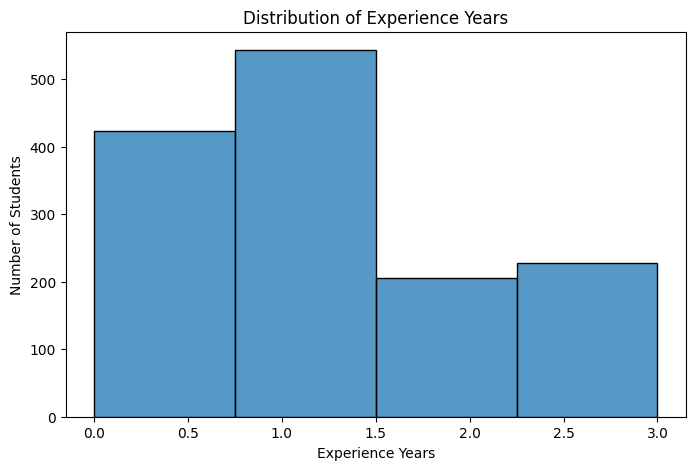

In [57]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["experience_years"],
    bins=4,
    kde=False)
plt.title("Distribution of Experience Years")
plt.xlabel("Experience Years")
plt.ylabel("Number of Students")
plt.show()

In [58]:
df["experience_years"].value_counts().sort_index()

,count
experience_years,
0,423
1,543
2,205
3,228


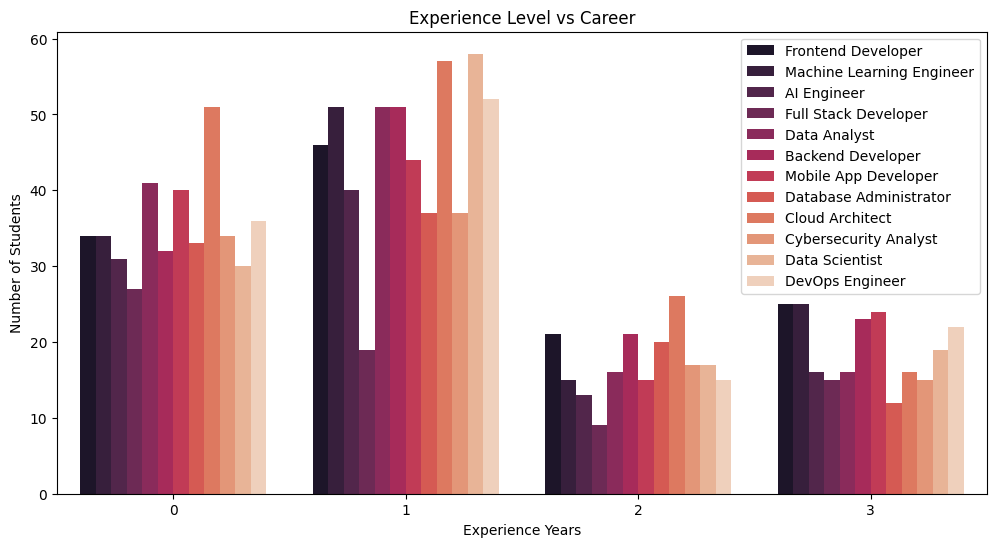

In [59]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x="experience_years",
    hue="target_career",palette="rocket")
plt.title("Experience Level vs Career")
plt.xlabel("Experience Years")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.legend()
plt.show()

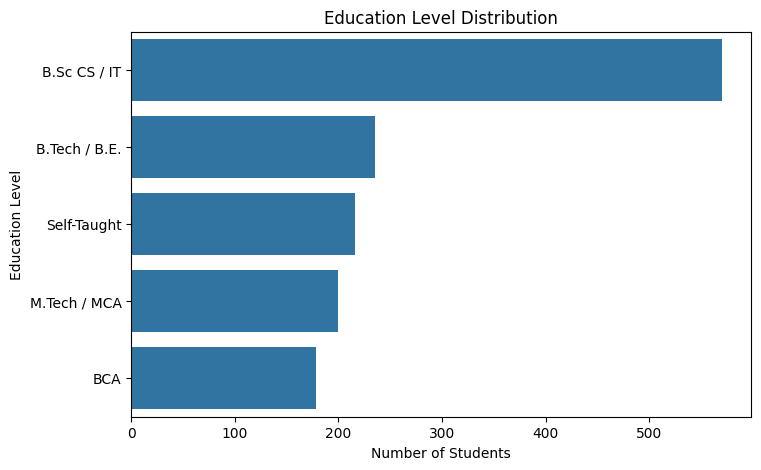

In [60]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    y="education_level",
    order=df["education_level"].value_counts().index)
plt.title("Education Level Distribution")
plt.xlabel("Number of Students")
plt.ylabel("Education Level")
plt.show()

In [61]:
skill_counts = df[skill_columns].sum().sort_values(ascending=False)
print(skill_counts)

git                     999
python                  888
sql                     849
docker                  772
linux                   656
aws                     571
postgresql              471
fastapi_flask           417
pandas_numpy            400
ci_cd                   374
nosql                   359
scikit_learn            348
javascript              303
typescript              301
deep_learning           298
kubernetes              292
nodejs                  284
terraform               268
nlp                     249
azure_gcp               245
html_css                235
java                    234
react                   232
pytorch_tensorflow      227
mongodb                 215
cybersecurity_basics    211
computer_vision         185
django                  156
penetration_testing     152
flutter_react_native    149
c_cpp                   141
angular_vue             106
dtype: int64


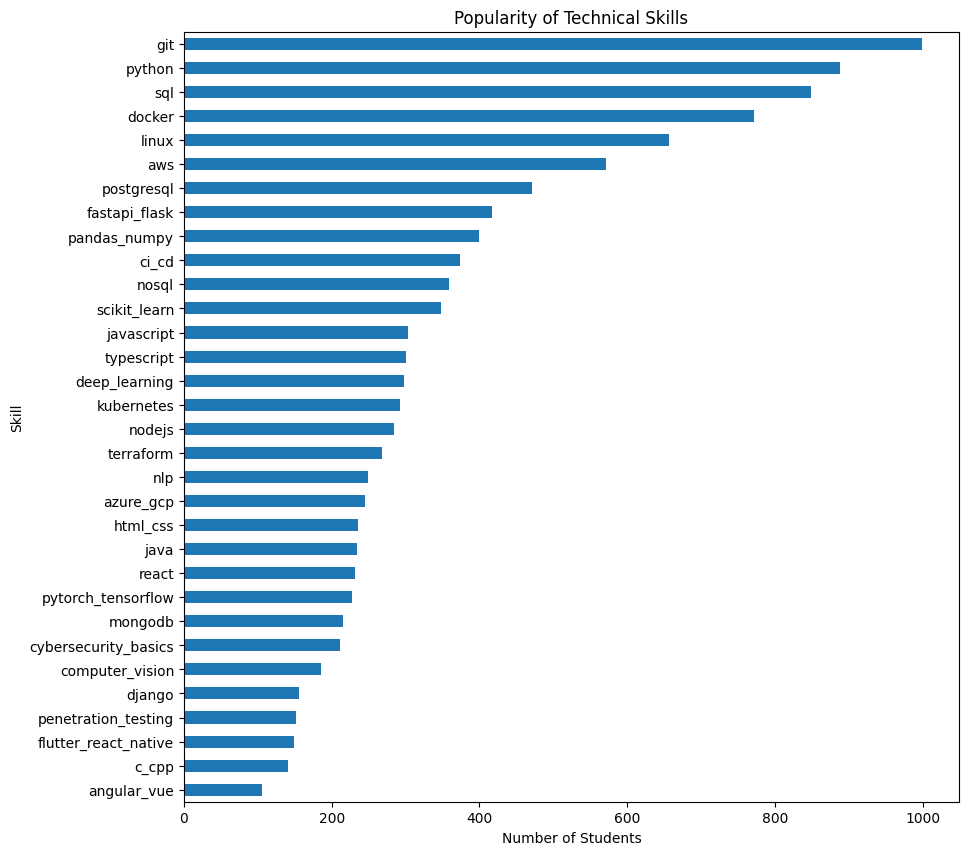

In [62]:
plt.figure(figsize=(10,10))
skill_counts.plot(kind="barh")
plt.title("Popularity of Technical Skills")
plt.xlabel("Number of Students")
plt.ylabel("Skill")
plt.gca().invert_yaxis()
plt.show()

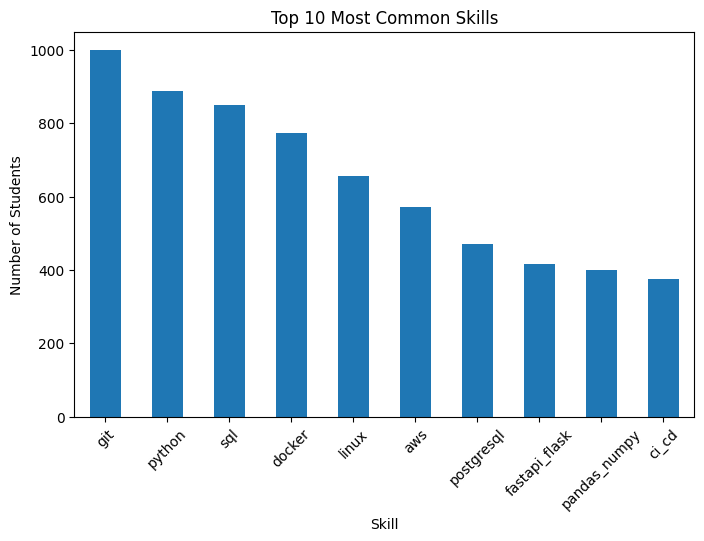

In [63]:
top_skills = skill_counts.head(10)
plt.figure(figsize=(8,5))
top_skills.plot(kind="bar")
plt.title("Top 10 Most Common Skills")
plt.xlabel("Skill")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.show()

In [64]:
df["total_skills"] = df[skill_columns].sum(axis=1)

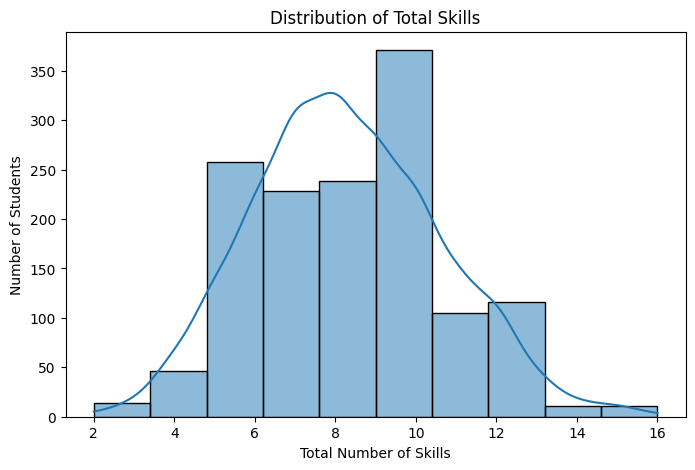

In [65]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["total_skills"],
    bins=10,
    kde=True)
plt.title("Distribution of Total Skills")
plt.xlabel("Total Number of Skills")
plt.ylabel("Number of Students")
plt.show()

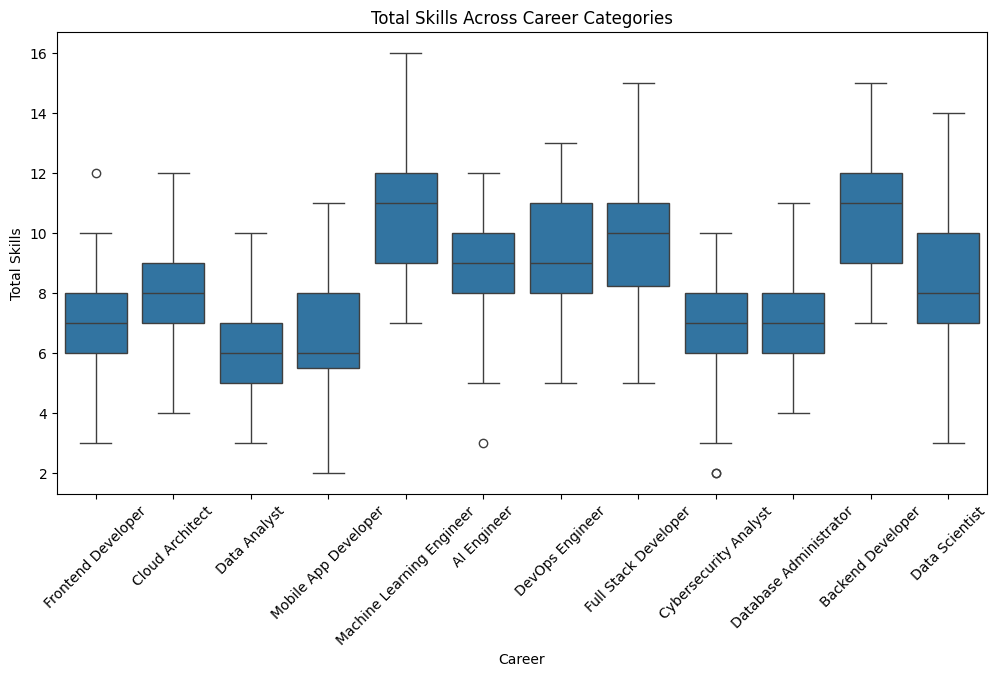

In [66]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="target_career",
    y="total_skills")
plt.title("Total Skills Across Career Categories")
plt.xlabel("Career")
plt.ylabel("Total Skills")
plt.xticks(rotation=45)
plt.show()

In [67]:
ml_skills = [
    "python",
    "pandas_numpy",
    "scikit_learn",
    "deep_learning",
    "pytorch_tensorflow",
    "nlp",
    "computer_vision"
]
df["ml_skill_count"] = df[ml_skills].sum(axis=1)

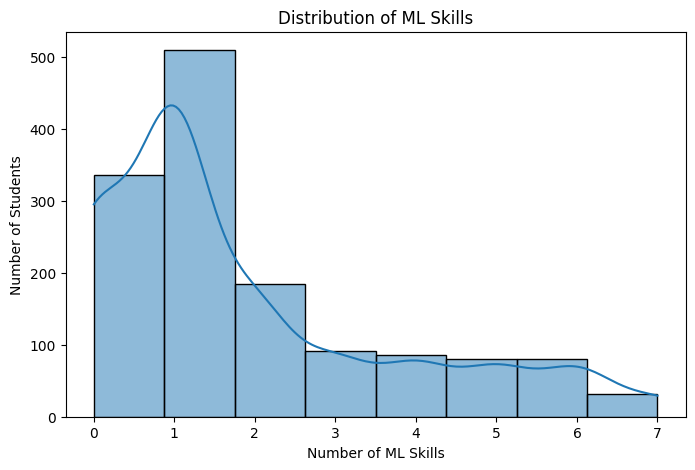

In [68]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["ml_skill_count"],
    bins=8,
    kde=True)
plt.title("Distribution of ML Skills")
plt.xlabel("Number of ML Skills")
plt.ylabel("Number of Students")
plt.show()

In [69]:
web_skills = [
    "html_css",
    "javascript",
    "typescript",
    "react",
    "angular_vue",
    "nodejs",
    "django",
    "fastapi_flask"
]
df["web_skill_count"] = df[web_skills].sum(axis=1)

In [70]:
df["experience_skill_score"] = (
    df["experience_years"] * df["total_skills"]
)

In [71]:
from sklearn.preprocessing import OneHotEncoder

# Ensure the column exists before attempting to encode
if "education_level" in df.columns:
    encoder = OneHotEncoder(
        drop="first",
        sparse_output=False
    )

    encoded = encoder.fit_transform(df[["education_level"]])

    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out(["education_level"]),
        index=df.index
    )

    df = pd.concat(
        [df.drop(columns=["education_level"]), encoded_df],
        axis=1
    )
else:
    print("'education_level' column has already been encoded and dropped.")

In [72]:
programming_skills = [
    "python",
    "java",
    "c_cpp",
    "javascript",
    "typescript"
]
df["programming_score"] = df[programming_skills].sum(axis=1)

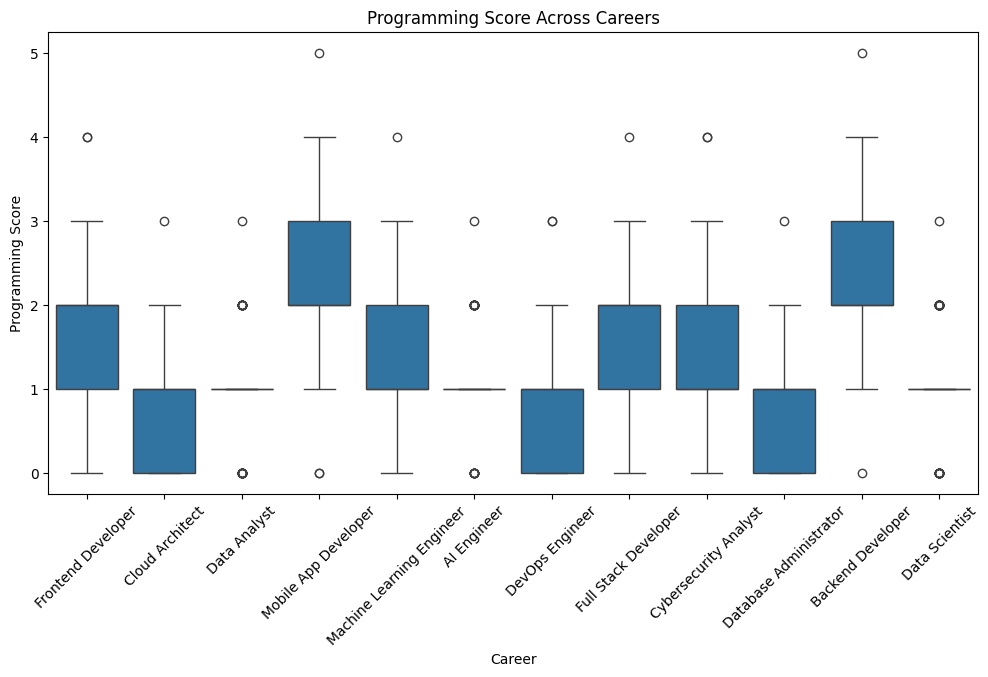

In [73]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="target_career",
    y="programming_score")
plt.title("Programming Score Across Careers")
plt.xlabel("Career")
plt.ylabel("Programming Score")
plt.xticks(rotation=45)
plt.show()

In [74]:
data_skills = [
    "python",
    "sql",
    "pandas_numpy",
    "scikit_learn",
    "postgresql",
    "mongodb"
]
df["data_skill_score"] = df[data_skills].sum(axis=1)

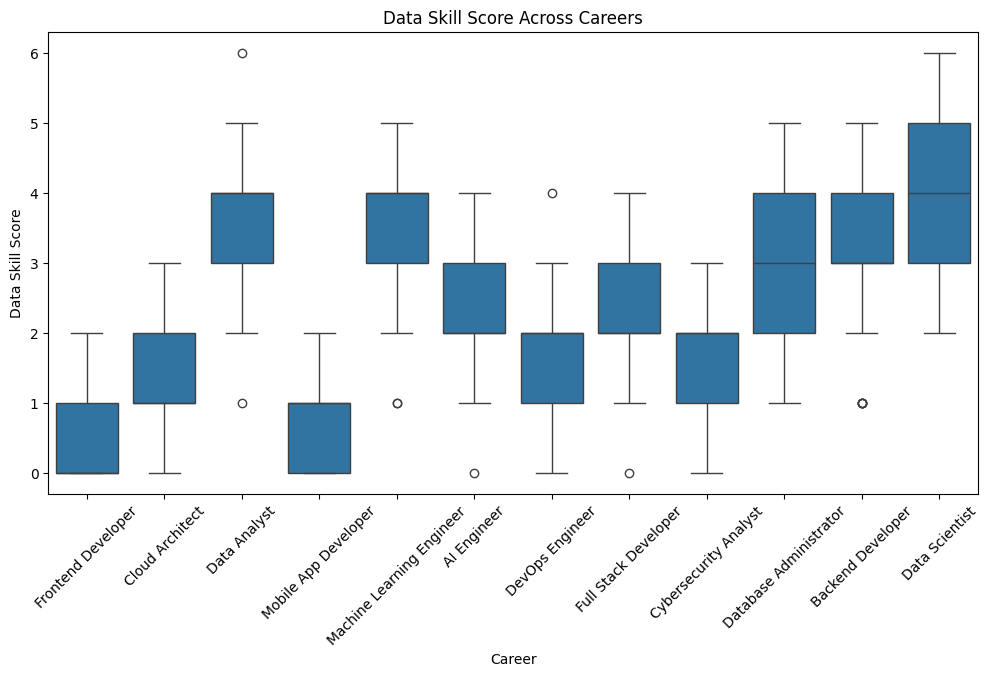

In [75]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="target_career",
    y="data_skill_score")
plt.title("Data Skill Score Across Careers")
plt.xlabel("Career")
plt.ylabel("Data Skill Score")
plt.xticks(rotation=45)
plt.show()

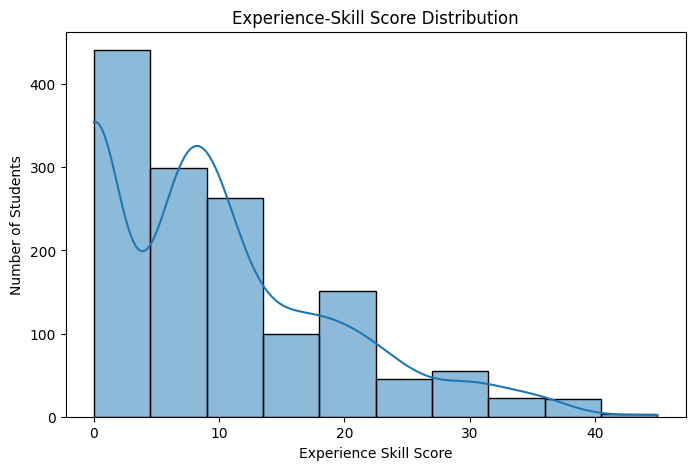

In [76]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["experience_skill_score"],
    bins=10,
    kde=True)
plt.title("Experience-Skill Score Distribution")
plt.xlabel("Experience Skill Score")
plt.ylabel("Number of Students")
plt.show()

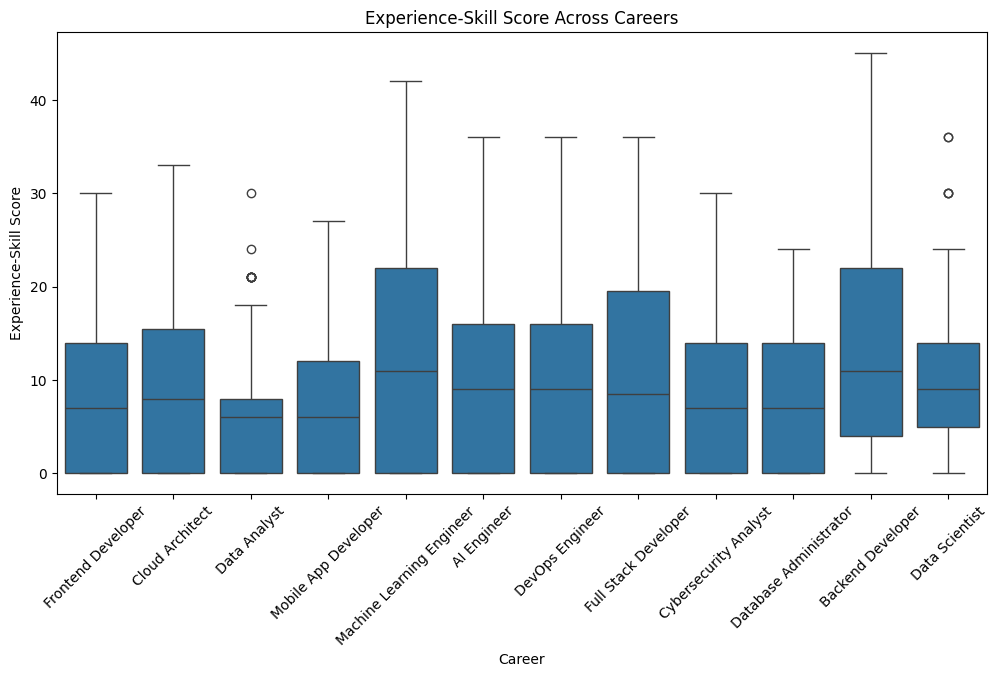

In [77]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="target_career",
    y="experience_skill_score")
plt.title("Experience-Skill Score Across Careers")
plt.xlabel("Career")
plt.ylabel("Experience-Skill Score")
plt.xticks(rotation=45)
plt.show()

In [78]:
df[
    [
        "experience_years",
        "total_skills",
        "ml_skill_count",
        "web_skill_count",
        "experience_skill_score",
        "programming_score",
        "data_skill_score"
    ]
].describe()

,experience_years,total_skills,ml_skill_count,web_skill_count,experience_skill_score,programming_score,data_skill_score
count,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000
mean,1.170122,8.282345,1.854896,1.453896,9.699786,1.334525,2.266619
std,1.035670,2.344670,1.897884,1.641028,9.332359,0.872175,1.405474
min,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,7.000000,1.000000,0.000000,0.000000,1.000000,1.000000
50%,1.000000,8.000000,1.000000,1.000000,8.000000,1.000000,2.000000
75%,2.000000,10.000000,3.000000,2.000000,15.000000,2.000000,3.000000
max,3.000000,16.000000,7.000000,7.000000,45.000000,5.000000,6.000000


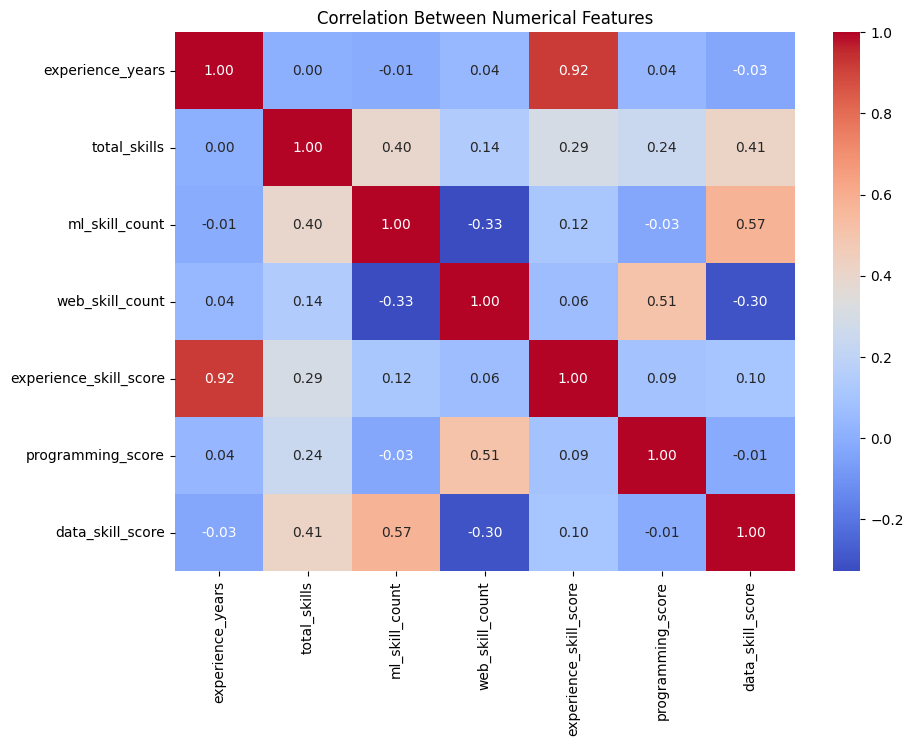

In [79]:
numeric_features = [
    "experience_years",
    "total_skills",
    "ml_skill_count",
    "web_skill_count",
    "experience_skill_score",
    "programming_score",
    "data_skill_score"
]
corr = df[numeric_features].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Between Numerical Features")
plt.show()

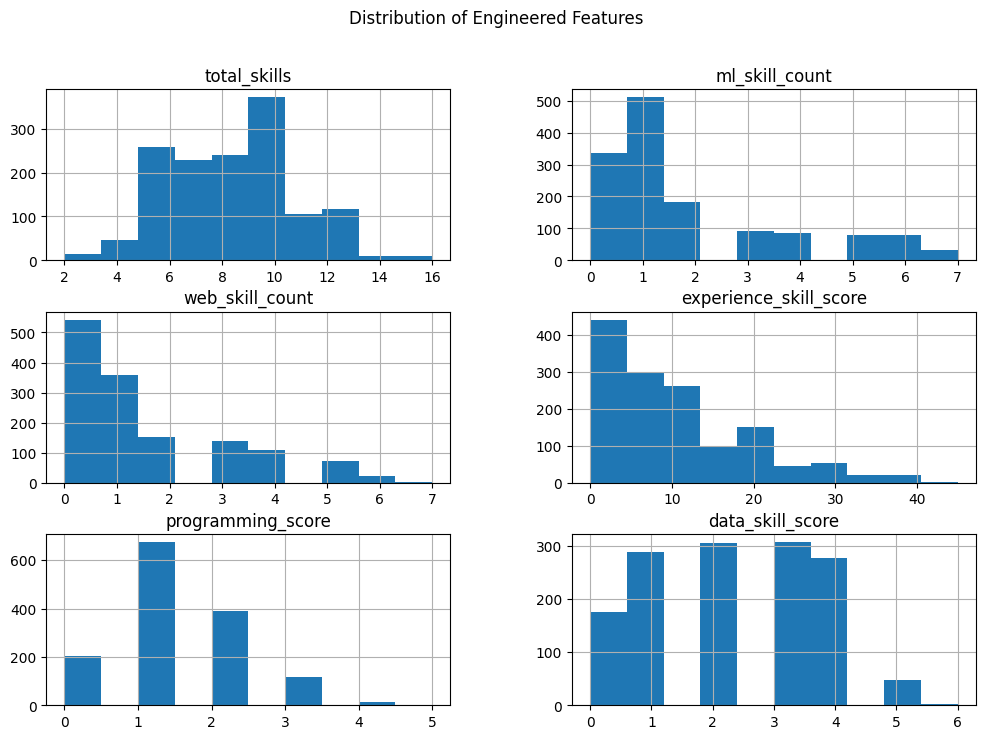

In [82]:
features = [
    "total_skills",
    "ml_skill_count",
    "web_skill_count",
    "experience_skill_score",
    "programming_score",
    "data_skill_score"
]
df[features].hist(
    figsize=(12,8),
    bins=10
)
plt.suptitle("Distribution of Engineered Features")
plt.show()

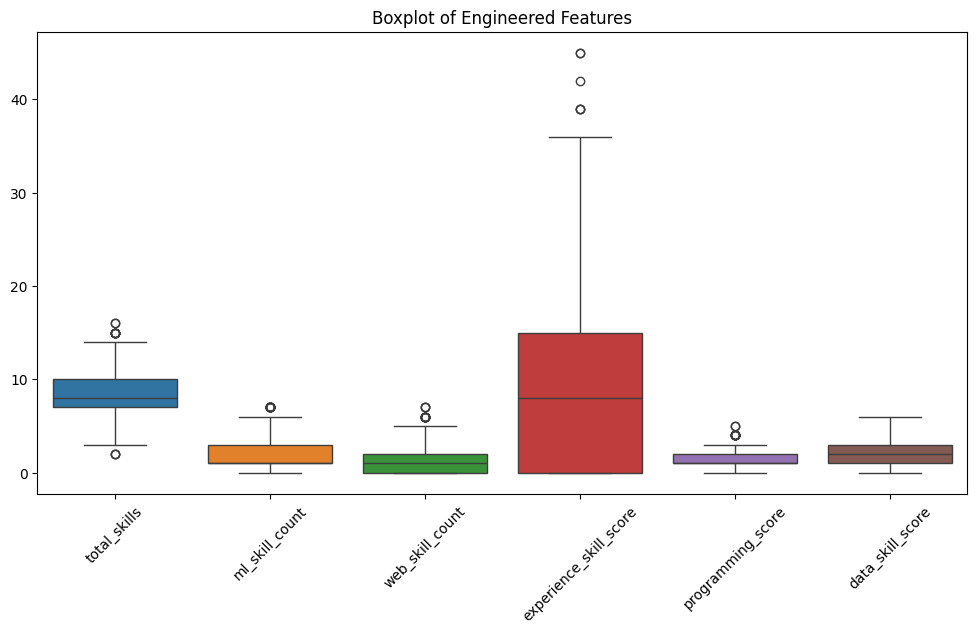

In [84]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df[features]
)
plt.title("Boxplot of Engineered Features")
plt.xticks(rotation=45)
plt.show()

In [95]:
career_skill_profile = df.groupby("target_career")[skill_columns].mean()
career_skill_profile

,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,fastapi_flask,...,kubernetes,git,linux,aws,azure_gcp,ci_cd,terraform,cybersecurity_basics,penetration_testing,flutter_react_native
target_career,,,,,,,,,,,,,,,,,,,,,
AI Engineer,0.870000,0.020000,0.200000,0.010000,0.020000,0.030000,0.020000,0.060000,0.050000,0.480000,...,0.130000,0.540000,0.410000,0.510000,0.060000,0.030000,0.060000,0.060000,0.060000,0.010000
Backend Developer,0.866142,0.811024,0.149606,0.047244,0.204724,0.031496,0.015748,0.070866,0.433071,0.818898,...,0.133858,0.818898,0.543307,0.543307,0.078740,0.472441,0.070866,0.047244,0.055118,0.039370
Cloud Architect,0.600000,0.033333,0.053333,0.060000,0.053333,0.026667,0.060000,0.020000,0.060000,0.060000,...,0.780000,0.233333,0.780000,0.753333,0.800000,0.546667,0.780000,0.460000,0.040000,0.033333
Cybersecurity Analyst,0.883495,0.213592,0.233010,0.048544,0.077670,0.038835,0.048544,0.029126,0.048544,0.000000,...,0.019417,0.873786,0.805825,0.388350,0.077670,0.194175,0.048544,0.766990,0.805825,0.058252
Data Analyst,0.822581,0.024194,0.040323,0.024194,0.040323,0.064516,0.080645,0.024194,0.056452,0.032258,...,0.008065,0.467742,0.250000,0.129032,0.080645,0.048387,0.032258,0.024194,0.072581,0.032258
Data Scientist,0.870968,0.032258,0.161290,0.024194,0.032258,0.064516,0.056452,0.040323,0.056452,0.500000,...,0.048387,0.838710,0.266129,0.491935,0.032258,0.056452,0.072581,0.024194,0.056452,0.056452
Database Administrator,0.558824,0.029412,0.049020,0.019608,0.019608,0.049020,0.049020,0.049020,0.068627,0.049020,...,0.049020,0.509804,0.774510,0.490196,0.058824,0.196078,0.019608,0.235294,0.058824,0.049020
DevOps Engineer,0.568000,0.056000,0.040000,0.040000,0.040000,0.080000,0.016000,0.064000,0.112000,0.216000,...,0.768000,0.856000,0.824000,0.808000,0.488000,0.736000,0.800000,0.024000,0.048000,0.048000
Frontend Developer,0.111111,0.055556,0.039683,0.825397,0.785714,0.833333,0.849206,0.476190,0.428571,0.158730,...,0.063492,0.896825,0.079365,0.023810,0.055556,0.047619,0.015873,0.039683,0.087302,0.015873


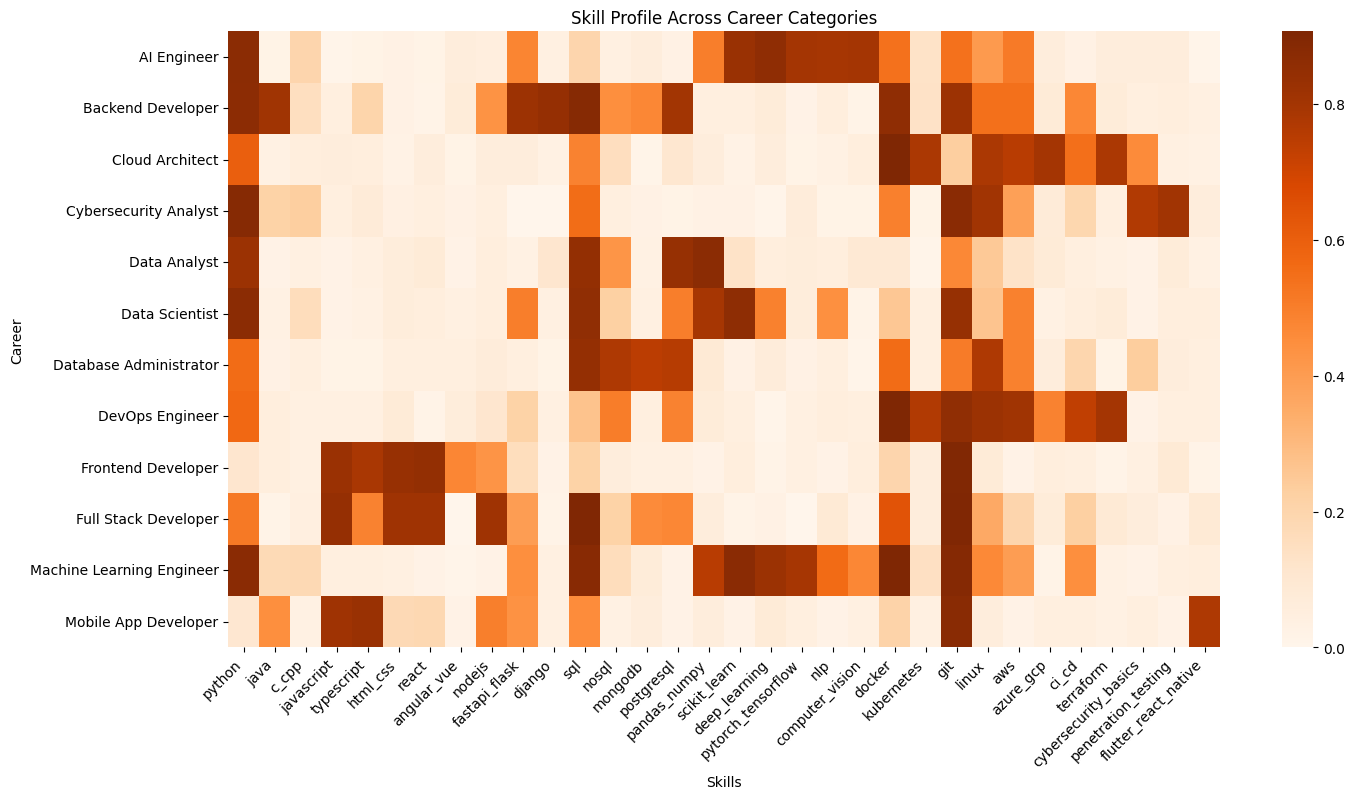

In [91]:
plt.figure(figsize=(16,8))
sns.heatmap(
    career_skill_profile,
    cmap="Oranges")
plt.title("Skill Profile Across Career Categories")
plt.xlabel("Skills")
plt.ylabel("Career")
plt.xticks(rotation=45, ha="right")
plt.show()

###EDA Summary
Exploratory Data Analysis was performed on the cleaned and feature-engineered career skills dataset. The analysis focused on understanding the distribution of career classes, education levels, experience, technical skills, and engineered features.

The career distribution was analyzed to identify possible class imbalance. Skill frequency analysis was used to determine the most common technical skills among respondents. The distributions of total_skills, ml_skill_count, web_skill_count, programming_score, data_skill_score, and experience_skill_score were also examined.

The relationship between skills and career categories was investigated using boxplots, count plots, and a career-skill heatmap. These analyses help identify whether different career categories have different skill profiles.

Correlation analysis was performed on numerical and engineered features to understand relationships between them. Outlier analysis was also performed on numerical features before proceeding to machine learning.

Based on the EDA, the dataset is now ready for the next stage: feature selection, train-test splitting, model training, and evaluation.